# Retail Sales Forecasting using Machine Learning

This notebook is a beginner-friendly, industry-style walkthrough covering: Problem statement, EDA, cleaning, feature engineering, model building, evaluation, forecasting, business insights, and presentation material.

**Dataset columns:** `date`, `sales`, `promotion`
**Objectives:** Forecast sales, analyze seasonality, quantify promotion impact, and produce business recommendations.

In [9]:
# Imports and load data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

df = pd.read_csv('data/retail_sales_dummy.csv', parse_dates=['date'])
df.sort_values('date', inplace=True)
df.reset_index(drop=True, inplace=True)
df.head()

,date,sales,promotion
0,2024-01-01,48,0
1,2024-01-02,38,0
2,2024-01-03,55,0
3,2024-01-04,21,0
4,2024-01-05,30,1


In [10]:
# Basic dataset info and expected output
print(df.shape)
print(df.dtypes)
df.describe()

(120, 3)
date         datetime64[us]
sales                 int64
promotion             int64
dtype: object


,date,sales,promotion
count,120,120.000000,120.000000
mean,2024-02-29 12:00:00,42.941667,0.191667
min,2024-01-01 00:00:00,20.000000,0.000000
25%,2024-01-30 18:00:00,33.000000,0.000000
50%,2024-02-29 12:00:00,43.500000,0.000000
75%,2024-03-30 06:00:00,54.250000,0.000000
max,2024-04-29 00:00:00,67.000000,1.000000
std,NaN,12.687780,0.395263


## Exploratory Data Analysis (EDA) - Theory
Visualize trends, seasonality, distribution, promotion effects, and outliers. Use rolling statistics to reveal short-term trends.

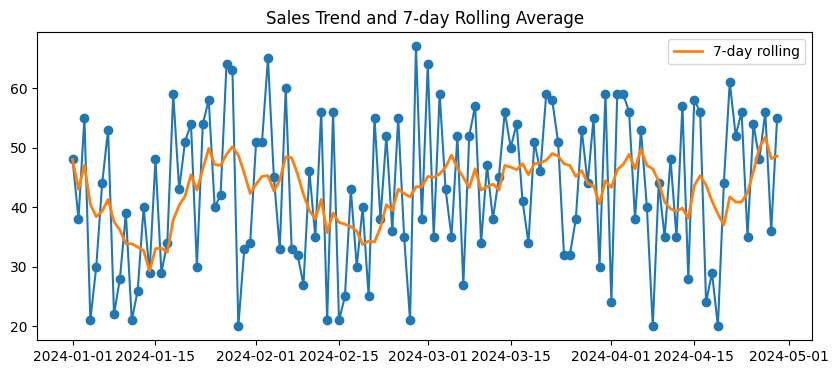

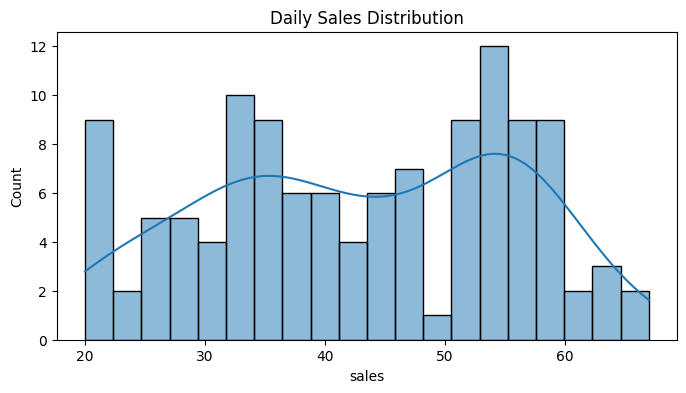

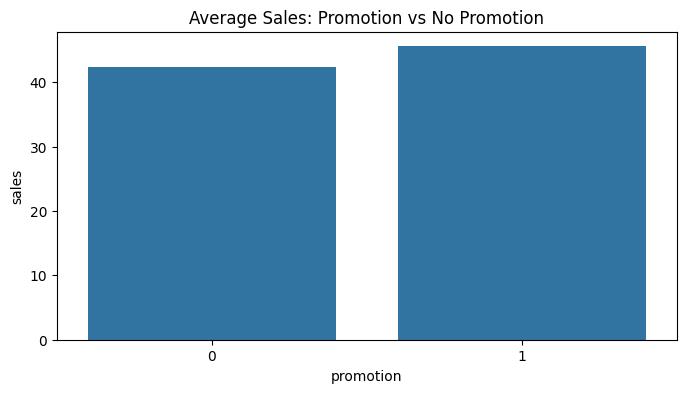

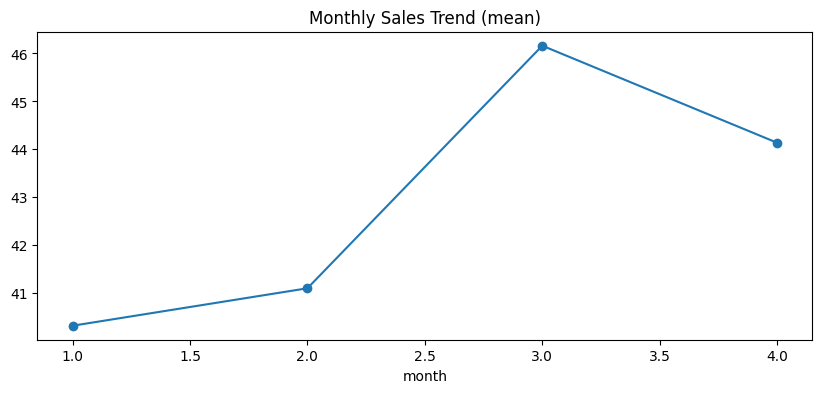

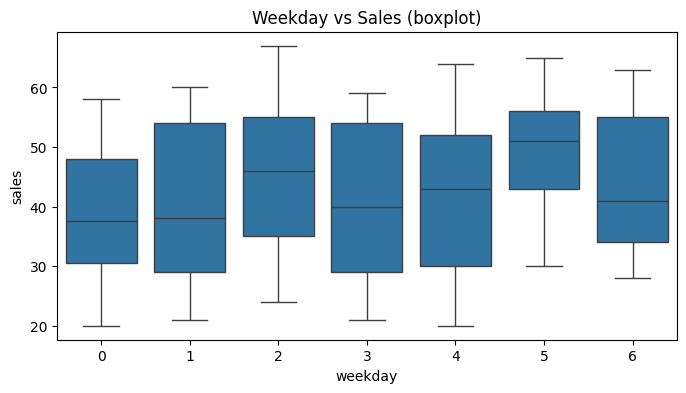

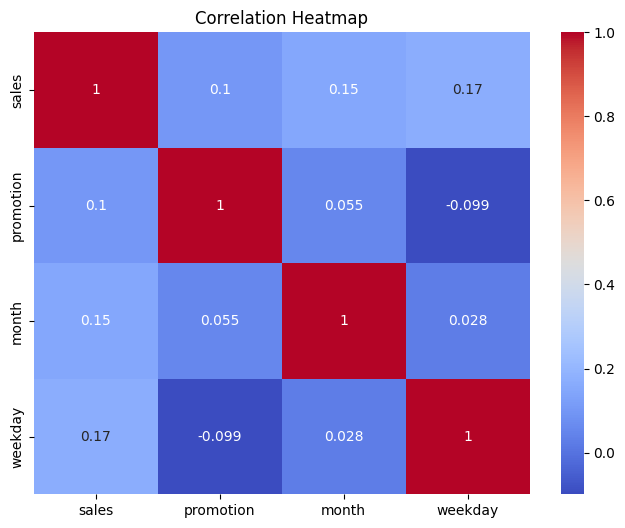

In [11]:
# EDA graphs (multiple plots). Expected: several figures showing trends and relationships.
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['weekday'] = df['date'].dt.weekday
df['is_weekend'] = df['weekday'] >= 5
df['rolling_7'] = df['sales'].rolling(7, min_periods=1).mean()

plt.figure(figsize=(10,4))
plt.plot(df['date'], df['sales'], marker='o', linestyle='-')
plt.plot(df['date'], df['rolling_7'], label='7-day rolling', linewidth=2)
plt.title('Sales Trend and 7-day Rolling Average')
plt.legend()
plt.show()

plt.figure(figsize=(8,4))
sns.histplot(df['sales'], bins=20, kde=True)
plt.title('Daily Sales Distribution')
plt.show()

plt.figure(figsize=(8,4))
sns.barplot(data=df.groupby('promotion')['sales'].mean().reset_index(), x='promotion', y='sales')
plt.title('Average Sales: Promotion vs No Promotion')
plt.show()

plt.figure(figsize=(10,4))
df.groupby('month')['sales'].mean().plot(marker='o')
plt.title('Monthly Sales Trend (mean)')
plt.show()

plt.figure(figsize=(8,4))
sns.boxplot(x='weekday', y='sales', data=df)
plt.title('Weekday vs Sales (boxplot)')
plt.show()

plt.figure(figsize=(8,6))
sns.heatmap(df[['sales','promotion','month','weekday']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

**Common EDA mistakes:** Not converting `date` to datetime; ignoring promotion encoding; plotting unsmoothed noisy series.
**Best practices:** Always visualize aggregated and rolling metrics; check for seasonality and promotion effects; document findings.

## Data Cleaning - Theory
Handle missing values, duplicates, wrong types, and obvious outliers. For time series, prefer forward/backward fill for short gaps or imputation for longer gaps.

In [12]:
# Data cleaning examples and expected outputs
print('Missing values:
', df.isna().sum())
df = df.drop_duplicates()
# If small gaps exist, forward fill sales (example)
df['sales'] = df['sales'].fillna(method='ffill')
df['promotion'] = df['promotion'].fillna(0).astype(int)
df.head()

SyntaxError: unterminated string literal (detected at line 2) (1521728429.py, line 2)

## Feature Engineering - Theory
Create calendar features, lags, rolling means, and promotion interaction terms. Keep features interpretable for business stakeholders.

In [ ]:
# Feature engineering
df['dayofyear'] = df['date'].dt.dayofyear
df['lag_1'] = df['sales'].shift(1).fillna(method='bfill')
df['rolling_7'] = df['sales'].rolling(7, min_periods=1).mean()
# Interaction: promotion effect per month
df['promo_month_interaction'] = df['promotion'] * df['month']
df.dropna(inplace=True)
df.head()

## Model Building - Theory
Start simple (Linear Regression), then try tree-based models (Random Forest). Use cross-validation and compare metrics like MAE and RMSE.

In [ ]:
# Prepare features and target
features = ['dayofyear','month','weekday','is_weekend','promotion','lag_1','rolling_7']
X = df[features]
y = df['sales']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

# Metrics
def print_metrics(y_true, y_pred, name='model'):
    print(name)
    print('MAE:', mean_absolute_error(y_true, y_pred))
    print('RMSE:', mean_squared_error(y_true, y_pred, squared=False))
    print('R2:', r2_score(y_true, y_pred))

print_metrics(y_test, lr_pred, 'LinearRegression')
print_metrics(y_test, rf_pred, 'RandomForest')

In [ ]:
# Evaluation plots: Actual vs Predicted and residuals
plt.figure(figsize=(10,4))
plt.plot(df['date'].iloc[-len(y_test):], y_test.values, label='Actual')
plt.plot(df['date'].iloc[-len(y_test):], rf_pred, label='RF Pred')
plt.plot(df['date'].iloc[-len(y_test):], lr_pred, label='LR Pred')
plt.legend()
plt.title('Actual vs Predicted (test set)')
plt.show()

resid = y_test.values - rf_pred
plt.figure(figsize=(6,4))
sns.histplot(resid, kde=True)
plt.title('Residual Distribution (RF)')
plt.show()

# Feature importance
importances = rf.feature_importances_
feat_imp = pd.Series(importances, index=features).sort_values(ascending=False)
plt.figure(figsize=(6,4))
sns.barplot(x=feat_imp.values, y=feat_imp.index)
plt.title('Feature Importance (RF)')
plt.show()

## Forecasting - Theory
Retrain the chosen model on full historical data then predict future dates using engineered calendar features and reasonable assumptions for lag/rolling values.

In [ ]:
# Forecast next 30 days using RF model retrained on full data
full_X = df[features]
full_y = df['sales']
rf_full = RandomForestRegressor(n_estimators=200, random_state=42)
rf_full.fit(full_X, full_y)

# create future dataframe
last_date = df['date'].max()
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=30)
future = pd.DataFrame({'date': future_dates})
future['dayofyear'] = future['date'].dt.dayofyear
future['month'] = future['date'].dt.month
future['weekday'] = future['date'].dt.weekday
future['is_weekend'] = future['weekday'] >= 5
# For lag and rolling, use last observed values as simple approximation
future['lag_1'] = df['sales'].iloc[-1]
future['rolling_7'] = df['sales'].rolling(7).mean().iloc[-1]
future['promotion'] = 0  # assume no promotion by default; update as needed
future_X = future[['dayofyear','month','weekday','is_weekend','promotion','lag_1','rolling_7']]
future['forecast'] = rf_full.predict(future_X)

plt.figure(figsize=(10,4))
plt.plot(df['date'], df['sales'], label='Historical')
plt.plot(future['date'], future['forecast'], label='Forecast', linestyle='--')
plt.legend()
plt.title('Historical + 30-day Forecast')
plt.show()

future[['date','forecast']].head()

## Business Insights & Inventory Recommendation
- Analyze top months and promotion lift; increase inventory 20-30% ahead of strong months identified.
- If promotion lift is high and sustained, stock more SKU units and coordinate with marketing.

In [ ]:
# Top months and promotion impact
top_months = df.groupby('month')['sales'].sum().sort_values(ascending=False)
print('Top months by total sales:
', top_months)
promo_lift = df[df['promotion']==1]['sales'].mean() / df[df['promotion']==0]['sales'].mean() - 1
print(f'Promotion lift (avg %): {promo_lift:.2%}')

## Deliverables & Notes
- All code for the project is in this notebook and `train_model.py`.
- Use `requirements.txt` to install dependencies.

**Interview questions (sample):**
Q: How do promotions affect sales? A: Compute lift = mean(sales|promo)/mean(sales|no_promo)-1 and test significance.
Q: How do you validate a forecasting model? A: Holdout test set, cross-validation on time slices, check MAE/RMSE and business KPIs.